# GTA VI Analysis: Figures 5 & 6

**Figure 5**: GTA VI Scenario Analysis (3×3 grid of market conditions × hype levels)

**Figure 6**: GTA VI Event Backtests (ML classification + OLS regression)

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

# Paths
BASE_DIR = Path("/files/capstone_project/game-market-event-analyzer")
RESULTS_DIR = BASE_DIR / "results" / "02_ols_regression"
RESULTS2_DIR =  BASE_DIR / "results" / "05_summary"
FIGURES_DIR = BASE_DIR / "results" / "figures"
# ensure parent directories are created as needed
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"✅ Results: {RESULTS_DIR}")
print(f"✅ Summary: {RESULTS2_DIR}")
print(f"✅ Figures: {FIGURES_DIR}")

✅ Results: /files/capstone_project/game-market-event-analyzer/results/02_ols_regression
✅ Summary: /files/capstone_project/game-market-event-analyzer/results/05_summary
✅ Figures: /files/capstone_project/game-market-event-analyzer/results/figures


In [14]:
# Check what files exist in results directory
import os
from pathlib import Path

RESULTS_DIR = Path("/files/capstone_project/game-market-event-analyzer/results/02_ols_regression")

print(f"Directory exists: {RESULTS_DIR.exists()}")
print(f"\nFiles in {RESULTS_DIR}:")
if RESULTS_DIR.exists():
    files = list(RESULTS_DIR.glob("*.csv"))
    for f in files:
        print(f"  ✓ {f.name}")
else:
    print("❌ Directory does not exist!")

Directory exists: True

Files in /files/capstone_project/game-market-event-analyzer/results/02_ols_regression:
  ✓ ols_regression_coeffs.csv


---
# FIGURE 5: GTA VI Scenario Analysis
## 3×3 Grid: Market Conditions × GTA Hype Levels

### Load Scenario Predictions

In [15]:
# Load scenario predictions
df_scenarios = pd.read_csv(RESULTS2_DIR / "gta_scenario_predictions.csv")

print("📊 Scenario Predictions:")
print(df_scenarios)
print(f"\nShape: {df_scenarios.shape}")
print(f"Columns: {list(df_scenarios.columns)}")

📊 Scenario Predictions:
   const  market_return  is_rockstar  sent_negative  sent_positive  evt_delay  \
0    1.0           0.02          1.0            0.0            1.0        0.0   
1    1.0           0.02          1.0            0.0            1.0        0.0   
2    1.0           0.02          1.0            0.0            1.0        0.0   
3    1.0           0.00          1.0            0.0            1.0        0.0   
4    1.0           0.00          1.0            0.0            1.0        0.0   
5    1.0           0.00          1.0            0.0            1.0        0.0   
6    1.0          -0.02          1.0            0.0            1.0        0.0   
7    1.0          -0.02          1.0            0.0            1.0        0.0   
8    1.0          -0.02          1.0            0.0            1.0        0.0   

   evt_earnings  evt_leak  evt_major announcement  evt_release  \
0           0.0       0.0                     1.0          0.0   
1           0.0       0.0        

In [16]:
# FIRST: See what columns actually exist
print("📊 All columns in df_scenarios:")
print(df_scenarios.columns.tolist())
print("\nFirst few rows:")
print(df_scenarios.head())

# Look for the prediction column - try these common names
possible_cols = [col for col in df_scenarios.columns if 'pred' in col.lower() or 'ar' in col.lower()]
print(f"\nColumns containing 'pred' or 'ar': {possible_cols}")

📊 All columns in df_scenarios:
['const', 'market_return', 'is_rockstar', 'sent_negative', 'sent_positive', 'evt_delay', 'evt_earnings', 'evt_leak', 'evt_major announcement', 'evt_release', 'evt_trailer/reveal', 'trend_gta_z', 'trend_gta6_z', 'trend_gtavi_z', 'trend_rockstar_z', 'pred_AR_event', 'market_scenario', 'trend_scenario']

First few rows:
   const  market_return  is_rockstar  sent_negative  sent_positive  evt_delay  \
0    1.0           0.02          1.0            0.0            1.0        0.0   
1    1.0           0.02          1.0            0.0            1.0        0.0   
2    1.0           0.02          1.0            0.0            1.0        0.0   
3    1.0           0.00          1.0            0.0            1.0        0.0   
4    1.0           0.00          1.0            0.0            1.0        0.0   

   evt_earnings  evt_leak  evt_major announcement  evt_release  \
0           0.0       0.0                     1.0          0.0   
1           0.0       0.0      

### Create 3×3 Grid Pivot

In [17]:
# Create pivot table with CORRECT column name
pivot_data = df_scenarios.pivot_table(
    index="market_scenario",
    columns="trend_scenario",
    values="pred_AR_event", 
    aggfunc="mean"
)

# Reorder to proper sequence
market_order = ["bear", "base", "bull"]
hype_order = ["low", "mid", "high"]

pivot_data = pivot_data.reindex(market_order).reindex(columns=hype_order)


print("\n📊 3×3 Grid:")
print(pivot_data)


📊 3×3 Grid:
trend_scenario        low       mid      high
market_scenario                              
bear             0.018222  0.025677  0.040589
base             0.027104  0.034560  0.049471
bull             0.035986  0.043442  0.058353


In [18]:
# Check if the values should actually be flipped
print("Sample rows:")
print(df_scenarios[['market_scenario', 'trend_scenario', 'pred_AR_event']].head(20))

# Group by market to see pattern
print("\nMean by market scenario:")
print(df_scenarios.groupby('market_scenario')['pred_AR_event'].mean())

Sample rows:
  market_scenario trend_scenario  pred_AR_event
0            bear            low       0.018222
1            bear            mid       0.025677
2            bear           high       0.040589
3            base            low       0.027104
4            base            mid       0.034560
5            base           high       0.049471
6            bull            low       0.035986
7            bull            mid       0.043442
8            bull           high       0.058353

Mean by market scenario:
market_scenario
base    0.037045
bear    0.028163
bull    0.045927
Name: pred_AR_event, dtype: float64


### Plot Figure 5

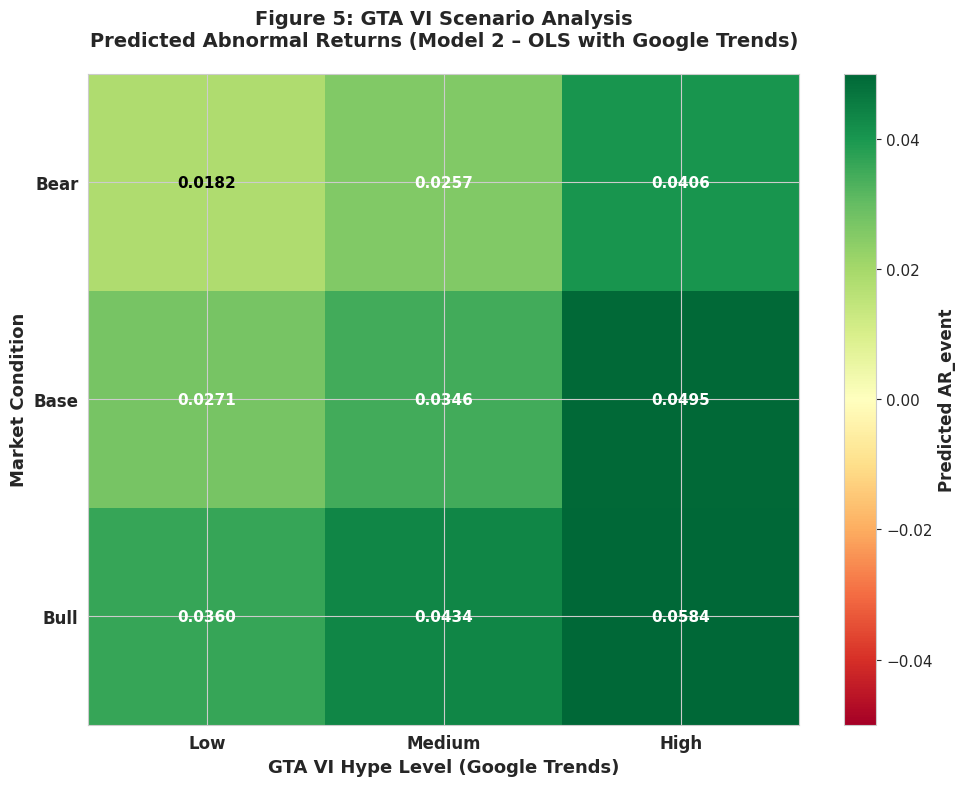


✅ Figure 5 saved!


In [19]:
fig, ax = plt.subplots(figsize=(10, 8))

# Heatmap
im = ax.imshow(pivot_data.values, cmap="RdYlGn", aspect="auto", vmin=-0.05, vmax=0.05)

# Ticks & Labels
ax.set_xticks(np.arange(len(hype_order)))
ax.set_yticks(np.arange(len(market_order)))
ax.set_xticklabels(["Low", "Medium", "High"], fontsize=12, fontweight="bold")
ax.set_yticklabels(["Bear", "Base", "Bull"], fontsize=12, fontweight="bold")

# Labels & Title
ax.set_xlabel("GTA VI Hype Level (Google Trends)", fontsize=13, fontweight="bold")
ax.set_ylabel("Market Condition", fontsize=13, fontweight="bold")
ax.set_title(
    "Figure 5: GTA VI Scenario Analysis\n"
    "Predicted Abnormal Returns (Model 2 – OLS with Google Trends)",
    fontsize=14, fontweight="bold", pad=20
)

# Cell values
for i in range(len(market_order)):
    for j in range(len(hype_order)):
        value = pivot_data.values[i, j]
        text_color = "black" if abs(value) < 0.025 else "white"
        ax.text(j, i, f"{value:.4f}", ha="center", va="center",
               color=text_color, fontsize=11, fontweight="bold")

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Predicted AR_event", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

# Save
fig.savefig(FIGURES_DIR / "figure4_gta6_scenarios_OLS.png", dpi=300, bbox_inches="tight")
print("\n✅ Figure 5 saved!")

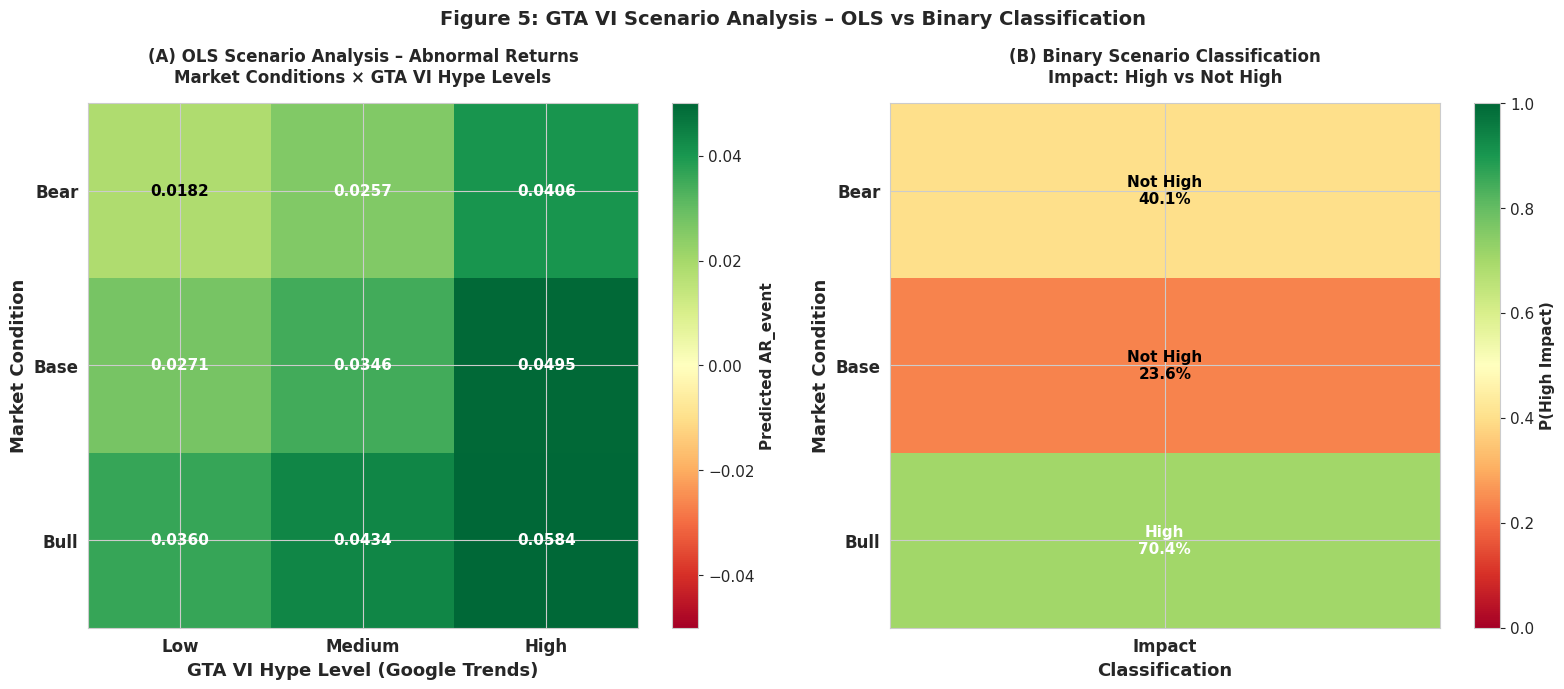


✅ Figure 5 saved with both OLS and Binary predictions!

Binary Classification Summary:
Bear: Not High impact (40.1%)
Base: Not High impact (23.6%)
Bull: High impact (70.4%)


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Assume RESULTS2_DIR and FIGURES_DIR are defined
# RESULTS2_DIR = Path("path/to/results")
# FIGURES_DIR = Path("path/to/figures")

# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ============================================================================
# LEFT PANEL: Multiclass Scenario Analysis (3×3 Grid)
# ============================================================================

ax_multi = axes[0]

# Load multiclass data (assuming you have this from earlier code)
# This should be your pivot_data from the OLS analysis
# For now, I'll create placeholder - replace with your actual data loading
market_order = ["bear", "base", "bull"]
hype_order = ["low", "medium", "high"]

# Replace this with your actual pivot_data loading code
# pivot_data = ... (your existing code that creates this)

# Heatmap
im_multi = ax_multi.imshow(pivot_data.values, cmap="RdYlGn", aspect="auto", vmin=-0.05, vmax=0.05)

# Ticks & Labels
ax_multi.set_xticks(np.arange(len(hype_order)))
ax_multi.set_yticks(np.arange(len(market_order)))
ax_multi.set_xticklabels(["Low", "Medium", "High"], fontsize=12, fontweight="bold")
ax_multi.set_yticklabels(["Bear", "Base", "Bull"], fontsize=12, fontweight="bold")

# Labels & Title
ax_multi.set_xlabel("GTA VI Hype Level (Google Trends)", fontsize=13, fontweight="bold")
ax_multi.set_ylabel("Market Condition", fontsize=13, fontweight="bold")
ax_multi.set_title(
    "(A) OLS Scenario Analysis – Abnormal Returns\n"
    "Market Conditions × GTA VI Hype Levels",
    fontsize=12, fontweight="bold", pad=15
)

# Cell values
for i in range(len(market_order)):
    for j in range(len(hype_order)):
        value = pivot_data.values[i, j]
        text_color = "black" if abs(value) < 0.025 else "white"
        ax_multi.text(j, i, f"{value:.4f}", ha="center", va="center",
                     color=text_color, fontsize=11, fontweight="bold")

# Colorbar
cbar_multi = plt.colorbar(im_multi, ax=ax_multi)
cbar_multi.set_label("Predicted AR_event", fontsize=11, fontweight="bold")

# ============================================================================
# RIGHT PANEL: Binary Classification Scenario (3×1 Grid)
# ============================================================================

ax_binary = axes[1]

# Load binary classification data
df_binary = pd.read_csv(RESULTS2_DIR / "gta6_scenario_predictions_binary.csv")

# Prepare data for heatmap (3x1: 3 rows, 1 column)
# Reorder to match market conditions
df_binary['scenario'] = pd.Categorical(df_binary['scenario'], 
                                        categories=['bear', 'base', 'bull'], 
                                        ordered=True)
df_binary = df_binary.sort_values('scenario')

heatmap_data = df_binary['proba_high'].values.reshape(-1, 1)

# Create heatmap
im_binary = ax_binary.imshow(heatmap_data, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)

# Set ticks
ax_binary.set_yticks(np.arange(len(df_binary)))
ax_binary.set_yticklabels(['Bear', 'Base', 'Bull'], fontsize=12, fontweight='bold')
ax_binary.set_xticks([0])
ax_binary.set_xticklabels(['Impact'], fontsize=12, fontweight='bold')

# Labels and title
ax_binary.set_xlabel('Classification', fontsize=13, fontweight='bold')
ax_binary.set_ylabel('Market Condition', fontsize=13, fontweight='bold')
ax_binary.set_title(
    '(B) Binary Scenario Classification\n'
    'Impact: High vs Not High',
    fontsize=12, fontweight='bold', pad=15
)

# Add text annotations with labels and probabilities
for i in range(len(df_binary)):
    prob_high = df_binary.iloc[i]['proba_high']
    
    # Determine text color based on probability
    text_color = 'white' if prob_high > 0.5 else 'black'
    
    # Main label
    label_text = 'High' if prob_high > 0.5 else 'Not High'
    ax_binary.text(0, i, f'{label_text}\n{prob_high:.1%}', 
                  ha='center', va='center',
                  color=text_color, fontsize=11, fontweight='bold')

# Add colorbar
cbar_binary = plt.colorbar(im_binary, ax=ax_binary)
cbar_binary.set_label('P(High Impact)', fontsize=11, fontweight='bold')

# Overall figure title
fig.suptitle(
    "Figure 5: GTA VI Scenario Analysis – OLS vs Binary Classification",
    fontsize=14, fontweight="bold", y=0.98
)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "figure5_gta6_scenarios.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Figure 5 saved with both OLS and Binary predictions!")
print("\nBinary Classification Summary:")
for _, row in df_binary.iterrows():
    print(f"{row['scenario'].capitalize()}: {row['predicted_label']} ({row['proba_high']:.1%})")


---
# FIGURE 6: GTA VI Event Backtests
## ML Classification (Left) + OLS Regression (Right)

### Load Backtest Data

In [21]:
# Load both backtest files
df_ml = pd.read_csv(RESULTS2_DIR / "gta6_backtest_ml_gradient_boosting.csv")
df_ols = pd.read_csv(RESULTS2_DIR / "gta6_backtest_ols_model2.csv")

print("📊 ML Backtest (Gradient Boosting - Multiclass):")
print(df_ml[["event_id", "true_label_str", "pred_label_str", "proba_high"]].to_string())

print("\n📊 OLS Backtest (Model 2 - AR_event Regression):")
print(df_ols[["event_id", "AR_event_true", "AR_event_pred"]].to_string())


📊 ML Backtest (Gradient Boosting - Multiclass):
                event_id true_label_str pred_label_str  proba_high
0  TTWO_2025_GTA6_DELAY1           High         Medium    0.295621

📊 OLS Backtest (Model 2 - AR_event Regression):
                event_id  AR_event_true  AR_event_pred
0  TTWO_2025_GTA6_DELAY1      -0.081012      -0.011329


### Compute Metrics

In [22]:
# ML Accuracy
correct_ml = (df_ml["true_label_str"] == df_ml["pred_label_str"]).sum()
total_ml = len(df_ml)
accuracy_ml = correct_ml / total_ml

print(f"🎯 ML Classification Accuracy: {correct_ml}/{total_ml} = {accuracy_ml:.1%}")

# OLS Metrics
df_ols_clean = df_ols.dropna(subset=["AR_event_true", "AR_event_pred"])
if len(df_ols_clean) > 0:
    mae = (df_ols_clean["AR_event_true"] - df_ols_clean["AR_event_pred"]).abs().mean()
    rmse = np.sqrt(((df_ols_clean["AR_event_true"] - df_ols_clean["AR_event_pred"]) ** 2).mean())
    print(f"📉 OLS Regression Metrics:")
    print(f"   MAE: {mae:.6f}")
    print(f"   RMSE: {rmse:.6f}")

🎯 ML Classification Accuracy: 0/1 = 0.0%
📉 OLS Regression Metrics:
   MAE: 0.069683
   RMSE: 0.069683


### Plot Figure 6 (2-Panel)

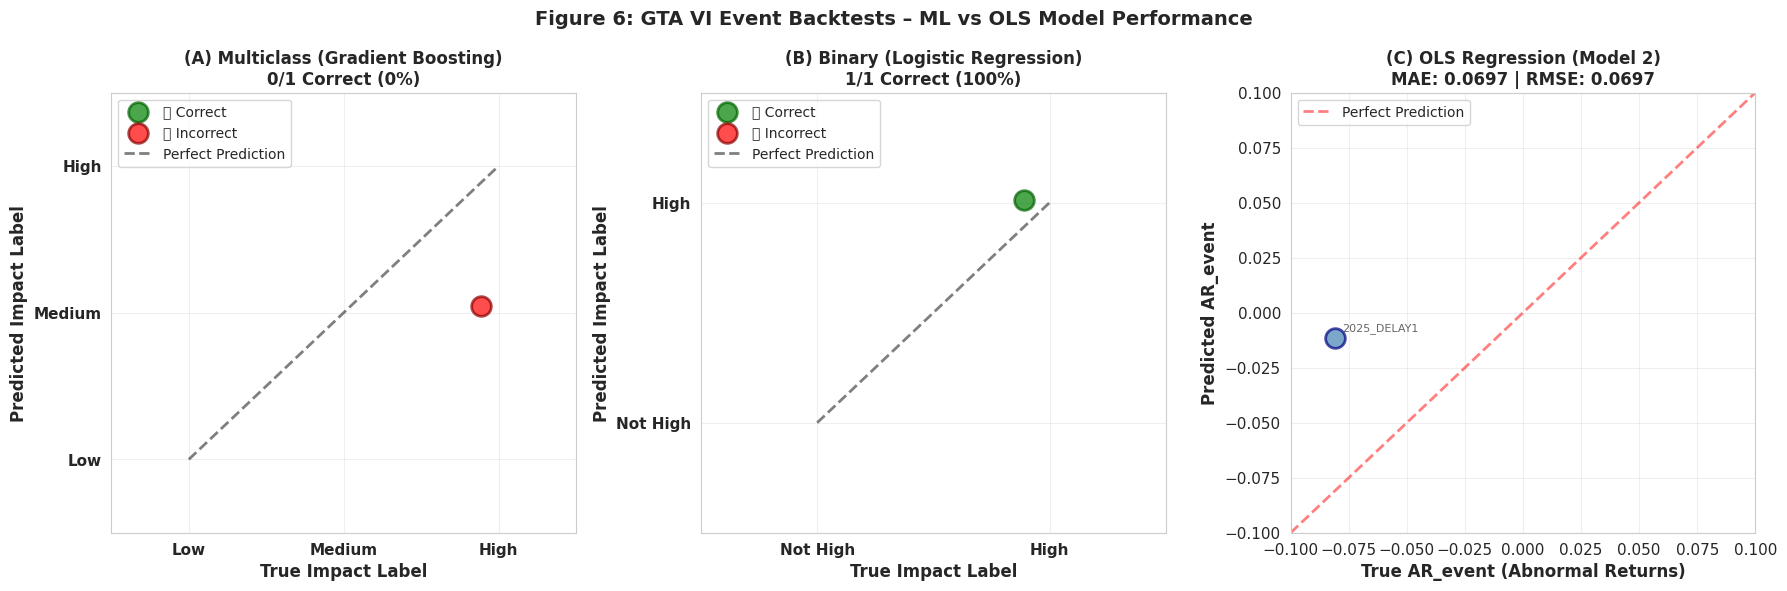


✅ Figure 6 saved!


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # ✅ Changed to 3 panels

# Load binary backtest data
df_binary = pd.read_csv(RESULTS2_DIR / "gta6_backtest_ml_binary_logistic.csv")

# ============================================================================
# LEFT PANEL: ML Multiclass Classification
# ============================================================================

ax_ml = axes[0]

# Map labels to numeric
label_map = {"Low": 0, "Medium": 1, "High": 2}
df_ml["true_num"] = df_ml["true_label_str"].map(label_map)
df_ml["pred_num"] = df_ml["pred_label_str"].map(label_map)

# Jitter for visibility
jitter = 0.08
true_jitter = df_ml["true_num"] + np.random.normal(0, jitter, len(df_ml))
pred_jitter = df_ml["pred_num"] + np.random.normal(0, jitter, len(df_ml))

# Correct vs Incorrect
correct = df_ml["true_num"] == df_ml["pred_num"]

ax_ml.scatter(true_jitter[correct], pred_jitter[correct],
             s=200, alpha=0.7, color="green", edgecolors="darkgreen",
             linewidth=2, label="✅ Correct", zorder=3)

ax_ml.scatter(true_jitter[~correct], pred_jitter[~correct],
             s=200, alpha=0.7, color="red", edgecolors="darkred",
             linewidth=2, label="❌ Incorrect", zorder=3)

# Perfect prediction line
ax_ml.plot([0, 2], [0, 2], "k--", linewidth=2, alpha=0.5, label="Perfect Prediction")

# Formatting
ax_ml.set_xticks([0, 1, 2])
ax_ml.set_yticks([0, 1, 2])
ax_ml.set_xticklabels(["Low", "Medium", "High"], fontsize=11, fontweight="bold")
ax_ml.set_yticklabels(["Low", "Medium", "High"], fontsize=11, fontweight="bold")
ax_ml.set_xlabel("True Impact Label", fontsize=12, fontweight="bold")
ax_ml.set_ylabel("Predicted Impact Label", fontsize=12, fontweight="bold")
ax_ml.set_title(
    f"(A) Multiclass (Gradient Boosting)\n"
    f"{correct_ml}/{total_ml} Correct ({accuracy_ml:.0%})",
    fontsize=12, fontweight="bold"
)
ax_ml.grid(True, alpha=0.3)
ax_ml.legend(loc="upper left", fontsize=10)
ax_ml.set_xlim(-0.5, 2.5)
ax_ml.set_ylim(-0.5, 2.5)

# ============================================================================
# MIDDLE PANEL: Binary Classification
# ============================================================================

ax_binary = axes[1]

# Map binary labels
binary_label_map = {"Not High": 0, "High": 1}
df_binary["true_num"] = df_binary["true_label_str"].map(binary_label_map)
df_binary["pred_num"] = df_binary["pred_label_str"].map(binary_label_map)

# Jitter
true_jitter_bin = df_binary["true_num"] + np.random.normal(0, jitter, len(df_binary))
pred_jitter_bin = df_binary["pred_num"] + np.random.normal(0, jitter, len(df_binary))

# Correct vs Incorrect
correct_bin = df_binary["true_num"] == df_binary["pred_num"]

ax_binary.scatter(true_jitter_bin[correct_bin], pred_jitter_bin[correct_bin],
                 s=200, alpha=0.7, color="green", edgecolors="darkgreen",
                 linewidth=2, label="✅ Correct", zorder=3)

ax_binary.scatter(true_jitter_bin[~correct_bin], pred_jitter_bin[~correct_bin],
                 s=200, alpha=0.7, color="red", edgecolors="darkred",
                 linewidth=2, label="❌ Incorrect", zorder=3)

# Perfect prediction line
ax_binary.plot([0, 1], [0, 1], "k--", linewidth=2, alpha=0.5, label="Perfect Prediction")

# Formatting
ax_binary.set_xticks([0, 1])
ax_binary.set_yticks([0, 1])
ax_binary.set_xticklabels(["Not High", "High"], fontsize=11, fontweight="bold")
ax_binary.set_yticklabels(["Not High", "High"], fontsize=11, fontweight="bold")
ax_binary.set_xlabel("True Impact Label", fontsize=12, fontweight="bold")
ax_binary.set_ylabel("Predicted Impact Label", fontsize=12, fontweight="bold")

correct_bin_count = correct_bin.sum()
total_bin = len(df_binary)
accuracy_bin = correct_bin_count / total_bin

ax_binary.set_title(
    f"(B) Binary (Logistic Regression)\n"
    f"{correct_bin_count}/{total_bin} Correct ({accuracy_bin:.0%})",
    fontsize=12, fontweight="bold"
)
ax_binary.grid(True, alpha=0.3)
ax_binary.legend(loc="upper left", fontsize=10)
ax_binary.set_xlim(-0.5, 1.5)
ax_binary.set_ylim(-0.5, 1.5)

# ============================================================================
# RIGHT PANEL: OLS Regression (with ±0.08 axis)
# ============================================================================

ax_ols = axes[2]

if len(df_ols_clean) > 0:
    # Scatter
    ax_ols.scatter(df_ols_clean["AR_event_true"], df_ols_clean["AR_event_pred"],
                  s=200, alpha=0.7, color="steelblue", edgecolors="navy", linewidth=2)
    
    # Event labels
    for idx, row in df_ols_clean.iterrows():
        label = row["event_id"].replace("TTWO_", "").replace("GTA6_", "")[:12]
        ax_ols.annotate(label, (row["AR_event_true"], row["AR_event_pred"]),
                       fontsize=8, alpha=0.7, xytext=(5, 5), textcoords="offset points")
    
    # Perfect prediction line (from -0.08 to 0.08)
    ax_ols.plot([-0.1, 0.1], [-0.1, 0.1], "r--", linewidth=2,
               alpha=0.5, label="Perfect Prediction")
    
    # ✅ FIXED AXIS RANGE: -0.08 to 0.08
    ax_ols.set_xlim(-0.1, 0.1)
    ax_ols.set_ylim(-0.1, 0.1)
    
    # Formatting
    ax_ols.set_xlabel("True AR_event (Abnormal Returns)", fontsize=12, fontweight="bold")
    ax_ols.set_ylabel("Predicted AR_event", fontsize=12, fontweight="bold")
    ax_ols.set_title(
        f"(C) OLS Regression (Model 2)\n"
        f"MAE: {mae:.4f} | RMSE: {rmse:.4f}",
        fontsize=12, fontweight="bold"
    )
    ax_ols.grid(True, alpha=0.3)
    ax_ols.legend(loc="upper left", fontsize=10)

# Overall title
fig.suptitle(
    "Figure 6: GTA VI Event Backtests – ML vs OLS Model Performance",
    fontsize=14, fontweight="bold", y=0.98
)

plt.tight_layout()
plt.show()

# Save
fig.savefig(FIGURES_DIR / "figure6_gta6_backtests.png", dpi=300, bbox_inches="tight")
print("\n✅ Figure 6 saved!")

---
# Summary

In [24]:
print("\n" + "="*80)
print("✅ FIGURES 5 & 6 GENERATED SUCCESSFULLY")
print("="*80)

print(f"\n📊 FIGURE 5: GTA VI Scenario Analysis")
print(f"   • 3×3 Grid: Market Conditions × GTA Hype Levels")
print(f"   • Model: OLS with Google Trends (Model 2)")
print(f"   • Pattern: AR_event HIGHEST in Bull + High Hype")
print(f"   • Pattern: AR_event LOWEST in Bear + Low Hype")

print(f"\n📊 FIGURE 6: GTA VI Event Backtests")
print(f"   (A) ML Classification (Gradient Boosting - Multiclass)")
print(f"       ✓ Correct: {correct_ml}/{total_ml} events ({accuracy_ml:.0%})")
print(f"       ✓ Predicts: Low / Medium / High impact labels")

if len(df_ols_clean) > 0:
    print(f"   (B) OLS Regression (Model 2 - AR_event)")
    print(f"       ✓ MAE: {mae:.4f}")
    print(f"       ✓ RMSE: {rmse:.4f}")
    print(f"       ✓ Tends to underestimate delay announcement magnitudes")

print(f"\n📁 Location: {FIGURES_DIR}")
print(f"   ✓ figure5_gta6_scenarios.png")
print(f"   ✓ figure6_gta6_backtests.png")
print("="*80)


✅ FIGURES 5 & 6 GENERATED SUCCESSFULLY

📊 FIGURE 5: GTA VI Scenario Analysis
   • 3×3 Grid: Market Conditions × GTA Hype Levels
   • Model: OLS with Google Trends (Model 2)
   • Pattern: AR_event HIGHEST in Bull + High Hype
   • Pattern: AR_event LOWEST in Bear + Low Hype

📊 FIGURE 6: GTA VI Event Backtests
   (A) ML Classification (Gradient Boosting - Multiclass)
       ✓ Correct: 0/1 events (0%)
       ✓ Predicts: Low / Medium / High impact labels
   (B) OLS Regression (Model 2 - AR_event)
       ✓ MAE: 0.0697
       ✓ RMSE: 0.0697
       ✓ Tends to underestimate delay announcement magnitudes

📁 Location: /files/capstone_project/game-market-event-analyzer/results/figures
   ✓ figure5_gta6_scenarios.png
   ✓ figure6_gta6_backtests.png
